# Resolution & Projection Transformation

`climdata.reproject` puts a dataset onto a target **coordinate reference system** and
**cell size**, wrapping `rasterio`/`rioxarray` for the warp and `xclim`/`pint` for unit
parsing.

This notebook works with two real datasets over **January 2014**:

| Dataset | Native CRS | Native resolution | Coverage |
|---|---|---|---|
| **HYRAS** (DWD) | EPSG:3035 — ETRS89-LAEA, *projected*, metres | 1 km | Germany |
| **MSWX** (GloH2O) | EPSG:4326 — WGS84, *geographic*, degrees | 0.1° | Global |

That contrast is the whole point. HYRAS takes a **linear** resolution (`"1 km"`), MSWX
takes an **angular** one (`"0.1 deg"`), and asking for the wrong pairing raises rather
than silently guessing.

---

## 1. Extract HYRAS for January 2014

A box over southern Germany, one month, daily mean temperature. The file is cached in
`./data` after the first run.

In [1]:
import warnings

import numpy as np
import xarray as xr
import rioxarray  # registers the .rio accessor
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import climdata
from climdata.grid import (
    infer_src_crs,
    parse_resolution,
    reproject,
    resolution_in_crs_units,
    to_angular,
    ResolutionCRSMismatch,
)

warnings.filterwarnings("ignore", category=UserWarning)

BOX = ["box.lat_min=47.5", "box.lat_max=50.0", "box.lon_min=7.5", "box.lon_max=10.5"]
PERIOD = ["time_range.start_date=2014-01-01", "time_range.end_date=2014-01-31"]

hyras = climdata.ClimData(
    overrides=["dataset=HYRAS", "variables=[tas]", *BOX, *PERIOD, "data_dir=./data"]
).extract()

hyras

⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/hyras_de/air_temperature_mean/tas_hyras_1_2014_v6-1_de.nc
✔️  Exists locally: ./data/HYRAS/TAS/tas_hyras_1_2014_v6-1_de.nc


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


<xarray.Dataset> Size: 16MB
Dimensions:  (time: 31, y: 276, x: 225)
Coordinates:
  * time     (time) datetime64[ns] 248B 2014-01-01 2014-01-02 ... 2014-01-31
    lon      (y, x) float64 497kB dask.array<chunksize=(276, 225), meta=np.ndarray>
    lat      (y, x) float64 497kB dask.array<chunksize=(276, 225), meta=np.ndarray>
  * x        (x) float64 2kB 4.132e+06 4.134e+06 ... 4.356e+06 4.356e+06
  * y        (y) float64 2kB 2.712e+06 2.714e+06 ... 2.986e+06 2.988e+06
Data variables:
    tas      (time, y, x) float64 15MB dask.array<chunksize=(31, 276, 225), meta=np.ndarray>
Attributes: (12/22)
    source:                 surface observations
    institution:            Deutscher Wetterdienst (DWD)
    Conventions:            CF-1.11
    title:                  gridded_temperature_dataset_(HYRAS TAS)
    realization:            v6-1
    project_id:             HYRAS
    ...                     ...
    variable_id:            tas
    ConventionsURL:         http://cfconventions.org/Data/cf-conventions/cf-c...
    license:                The HYRAS data, produced by DWD, is licensed unde...
    filename:               tas_hyras_1_2014_v6-1_de.nc
    comment:                Please be aware that the parameters are stored as...
    unique_dataset_id:      DWD_HYRAS_DE_tas_v6-1_2014_3213e948-fc0f-4f94-88b...

### What grid is this?

HYRAS records its projection in a CF `crs` variable. Subsetting drops that variable but
leaves the WKT behind on the data variable, so `climdata` looks there too.

In [2]:
print("grid_mapping pointer :", hyras.tas.attrs.get("grid_mapping"),
      "-> variable present?", "crs" in hyras.variables)
print("esri_pe_string present:", "esri_pe_string" in hyras.tas.attrs)

crs = infer_src_crs(hyras)
print("\ninferred CRS :", crs.to_string())
print("projected    :", crs.is_projected)
print("axis units   :", crs.axis_info[0].unit_name)

x_res = float(np.diff(hyras.x.values)[0])
y_res = float(np.diff(hyras.y.values)[0])
print(f"\nnative cell  : {x_res:.0f} m x {y_res:.0f} m")
print(f"grid         : {hyras.sizes['y']} rows x {hyras.sizes['x']} cols, "
      f"{hyras.sizes['time']} days")

grid_mapping pointer : crs -> variable present? False
esri_pe_string present: True

inferred CRS : EPSG:3035
projected    : True
axis units   : metre

native cell  : 1000 m x 1000 m
grid         : 276 rows x 225 cols, 31 days


So HYRAS is on a **projected** grid measured in metres. Its resolution is therefore
written as `"1 km"`, never as a number of degrees.

## 2. Parsing resolutions

Unit parsing is delegated to `xclim.core.units` (pint). Values are canonicalised to
**metres** (linear) or **degrees** (angular).

In [3]:
for text in ["1 km", "5km", "1000 m", "0.1 deg", "0.1°", "30 arcsec", "5 arcmin"]:
    res = parse_resolution(text)
    print(f"{text:>10s}  ->  {str(res):>16s}   (kind: {res.kind})")

print()
print("anisotropic :", parse_resolution(("5 km", "2 km")))
print("bare number :", parse_resolution(0.1), "-> adopts the target CRS axis units")

      1 km  ->            1000 m   (kind: linear)
       5km  ->            5000 m   (kind: linear)
    1000 m  ->            1000 m   (kind: linear)
   0.1 deg  ->           0.1 deg   (kind: angular)
      0.1°  ->           0.1 deg   (kind: angular)
 30 arcsec  ->    0.00833333 deg   (kind: angular)
  5 arcmin  ->     0.0833333 deg   (kind: angular)

anisotropic : 5000 x 2000 m
bare number : 0.1 -> adopts the target CRS axis units


## 3. The rule: resolution units must match the projection

HYRAS (projected, metres) takes linear resolutions. MSWX (geographic, degrees) takes
angular ones. The pairings are checked before any data moves.

In [4]:
pairs = [
    ("1 km",     "EPSG:3035", "HYRAS native grid"),
    ("5 km",     "EPSG:3035", "coarsened HYRAS"),
    ("0.1 deg",  "EPSG:4326", "MSWX native grid"),
    ("30 arcsec","EPSG:4326", "~1 km in degrees"),
    ("1 km",     "EPSG:4326", "HYRAS resolution on the MSWX CRS"),
    ("0.1 deg",  "EPSG:3035", "MSWX resolution on the HYRAS CRS"),
]

for res, crs_code, label in pairs:
    try:
        value = resolution_in_crs_units(res, crs_code)
        print(f"  OK      {res:>10s} + {crs_code:<10s} -> {value}   ({label})")
    except ResolutionCRSMismatch:
        print(f"  REJECT  {res:>10s} + {crs_code:<10s} -> ResolutionCRSMismatch   ({label})")

  OK            1 km + EPSG:3035  -> (1000.0, 1000.0)   (HYRAS native grid)
  OK            5 km + EPSG:3035  -> (5000.0, 5000.0)   (coarsened HYRAS)
  OK         0.1 deg + EPSG:4326  -> (0.1, 0.1)   (MSWX native grid)
  OK       30 arcsec + EPSG:4326  -> (0.008333333333333333, 0.008333333333333333)   (~1 km in degrees)
  REJECT        1 km + EPSG:4326  -> ResolutionCRSMismatch   (HYRAS resolution on the MSWX CRS)
  REJECT     0.1 deg + EPSG:3035  -> ResolutionCRSMismatch   (MSWX resolution on the HYRAS CRS)


### Why the last two are rejected

A kilometre is not a fixed number of degrees. Across the HYRAS domain alone the longitude
span of 1 km changes measurably, and by 70°N it has nearly tripled relative to the
equator — so no single value could describe the grid:

In [5]:
from pyproj import Geod

geod = Geod(ellps="WGS84")
print(f"{'latitude':>10s} {'Δlon':>10s} {'Δlat':>10s} {'anisotropy':>12s}")
for latitude in (0, 47.5, 50.0, 60, 70):
    d_lon, _, _ = geod.fwd(0, latitude, 90, 1_000)
    _, d_lat, _ = geod.fwd(0, latitude, 0, 1_000)
    d_lat -= latitude
    marker = "  <- HYRAS domain" if latitude in (47.5, 50.0) else ""
    print(f"{latitude:>9.1f}° {abs(d_lon):>10.5f} {abs(d_lat):>10.5f} "
          f"{abs(d_lon)/abs(d_lat):>11.2f}x{marker}")

  latitude       Δlon       Δlat   anisotropy
      0.0°    0.00898    0.00904        0.99x
     47.5°    0.01327    0.00899        1.48x  <- HYRAS domain
     50.0°    0.01395    0.00899        1.55x  <- HYRAS domain
     60.0°    0.01792    0.00898        2.00x
     70.0°    0.02619    0.00896        2.92x


The error quotes the numbers for *your* domain and names both ways out:

In [6]:
try:
    reproject(hyras, "EPSG:4326", "1 km")
except ResolutionCRSMismatch as err:
    print(err)

target_resolution="1 km" is a linear resolution, but target_projection="EPSG:4326" is a geographic CRS with axis units of degree.

A metric resolution has no fixed angular size: 1 km spans 0.0136 deg of longitude but 0.0090 deg of latitude at 48.7N, and 0.0262 deg x 0.0090 deg at 70N. There is no single correct value for this grid.

Choose one:
  - angular resolution   target_resolution="0.1 deg"
  - projected CRS        target_projection="EPSG:3035"   (ETRS89-LAEA, metres - Europe)
                         target_projection="EPSG:32632"  (UTM 32N, metres)


### The escape hatch

If you really want a metric grid expressed in degrees, `to_angular` will do it — but it
demands an explicit latitude, so it can never happen by accident. There is deliberately no
config flag for this.

In [7]:
res = to_angular("1 km", latitude=48.75)   # centre of the HYRAS box
print(f"1 km at 48.75°N  ->  {res.x:.5f}° lon x {res.y:.5f}° lat")

approx = reproject(hyras, "EPSG:4326", res)
print("shape:", dict(approx.sizes))

1 km at 48.75°N  ->  0.01360° lon x 0.00899° lat
shape: {'lon': 232, 'lat': 281, 'time': 31}


## 4. Coarsening HYRAS: 1 km to 5 km

Projected to projected, so the resolution stays linear. `tas` is a state variable, so
`bilinear` is the right resampling; a flux such as `pr` would want `average`.

In [8]:
coarse = reproject(hyras, "EPSG:3035", "5 km", method="bilinear")

print("native :", dict(hyras.sizes), "at", hyras.rio.resolution() if hasattr(hyras, "rio") else "1 km")
print("coarse :", dict(coarse.sizes), "at", coarse.rio.resolution())
print("CRS    :", coarse.rio.crs.to_string())
print("units  :", coarse.tas.attrs.get("units"))

print(f"\nJanuary 2014 mean, native : {float(hyras.tas.mean()):.3f} °C")
print(f"January 2014 mean, coarse : {float(coarse.tas.mean()):.3f} °C")

native : {'time': 31, 'y': 276, 'x': 225} at (1000.0, 1000.0)
coarse : {'x': 46, 'y': 57, 'time': 31} at (5000.0, -5000.0)
CRS    : EPSG:3035
units  : °C

January 2014 mean, native : 2.917 °C
January 2014 mean, coarse : 2.929 °C


### A cartopy projection for EPSG:3035

Cartopy needs a projection *object*, not an EPSG code. `ccrs.epsg(3035)` exists but looks
the code up over the network, so the parameters are given explicitly here — they are the
same ones the HYRAS `crs` variable carries.

In [9]:
# EPSG:3035 = ETRS89 / LAEA Europe, exactly as HYRAS records it.
HYRAS_CRS = ccrs.LambertAzimuthalEqualArea(
    central_longitude=10.0,
    central_latitude=52.0,
    false_easting=4321000.0,
    false_northing=3210000.0,
    globe=ccrs.Globe(ellipse="GRS80"),
)
PLATE = ccrs.PlateCarree()          # for anything already in EPSG:4326

# Same ground on every panel, so the comparisons are fair.
EXTENT = [7.4, 10.55, 47.45, 50.05]


def decorate(ax, title):
    """Coastlines, borders, lakes and labelled gridlines on a GeoAxes."""
    ax.set_extent(EXTENT, crs=PLATE)
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="0.25")
    ax.add_feature(cfeature.LAKES, facecolor="none", edgecolor="0.45", linewidth=0.4)
    gridlines = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gridlines.top_labels = gridlines.right_labels = False
    ax.set_title(title)


# The domain is landlocked, so the coastline draws nothing; the German border is what
# outlines the white area, where HYRAS simply has no data.

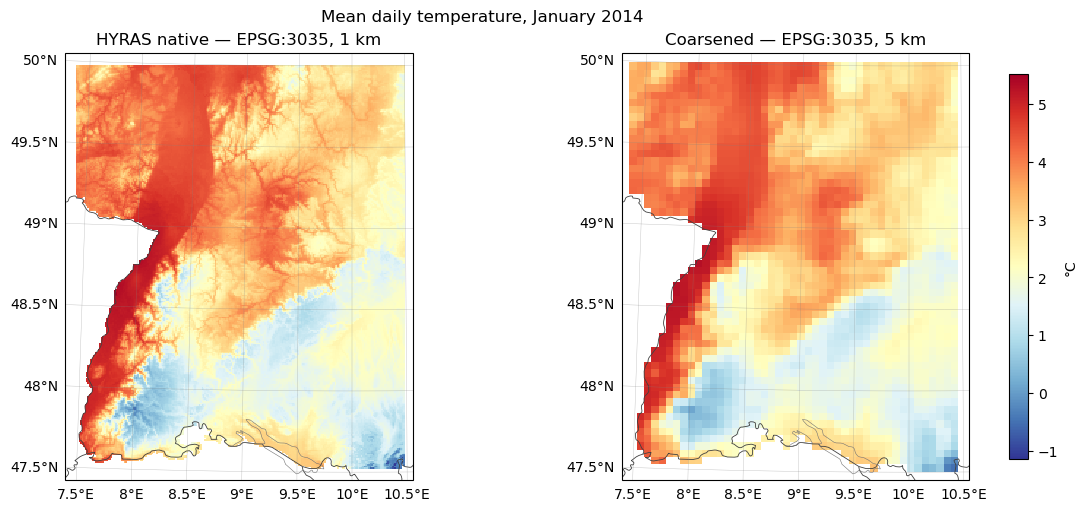

In [10]:
january_mean_native = hyras.tas.mean("time")
january_mean_coarse = coarse.tas.mean("time")

# One colour scale for both panels, taken from the native field.
vmin = float(january_mean_native.min())
vmax = float(january_mean_native.max())

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": HYRAS_CRS},
    constrained_layout=True,
)
style = dict(cmap="RdYlBu_r", vmin=vmin, vmax=vmax, transform=HYRAS_CRS, add_colorbar=False)

mesh = january_mean_native.plot(ax=axes[0], **style)
january_mean_coarse.plot(ax=axes[1], **style)

decorate(axes[0], "HYRAS native — EPSG:3035, 1 km")
decorate(axes[1], "Coarsened — EPSG:3035, 5 km")

colorbar = fig.colorbar(mesh, ax=axes, shrink=0.9, pad=0.02)
colorbar.set_label("°C")
fig.suptitle("Mean daily temperature, January 2014")
plt.show()

## 5. Onto the MSWX grid: projected to geographic

To compare HYRAS against MSWX you need them on one grid. MSWX is EPSG:4326 at 0.1°, so
that becomes the target — and the resolution must now be **angular**.

In [11]:
MSWX_CRS = "EPSG:4326"
MSWX_RES = "0.1 deg"

hyras_on_mswx = reproject(hyras, MSWX_CRS, MSWX_RES, method="average")

print("CRS        :", hyras_on_mswx.rio.crs.to_string())
print("shape      :", dict(hyras_on_mswx.sizes))
print("resolution :", hyras_on_mswx.rio.resolution())
print("coords     :", [c for c in hyras_on_mswx.coords])
print(f"lon        : {float(hyras_on_mswx.lon.min()):.2f} to {float(hyras_on_mswx.lon.max()):.2f}")
print(f"lat        : {float(hyras_on_mswx.lat.min()):.2f} to {float(hyras_on_mswx.lat.max()):.2f}")

CRS        : EPSG:4326
shape      : {'lon': 34, 'lat': 27, 'time': 31}
resolution : (0.1, -0.1)
coords     : ['lon', 'lat', 'time', 'crs']
lon        : 7.35 to 10.65
lat        : 47.45 to 50.05


Note the output coordinates come back named `lon`/`lat` because the target is
geographic; for a projected target they are `x`/`y`.

Aggregating 1 km cells to 0.1° is a coarsening of roughly 8x in each direction, so
`method="average"` is used rather than `bilinear` — it takes the mean of the contributing
source cells instead of sampling four of them.

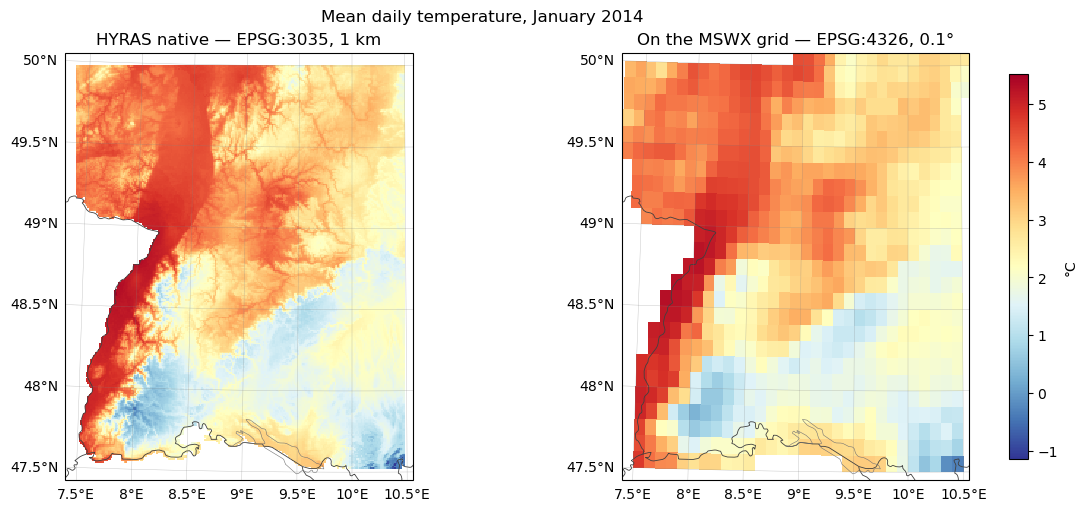

In [12]:
# The two panels hold data in *different* CRSs. Drawing them in one map projection is
# just a matter of giving each its own `transform=`; cartopy warps them to match.
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": HYRAS_CRS},
    constrained_layout=True,
)
common = dict(cmap="RdYlBu_r", vmin=vmin, vmax=vmax, add_colorbar=False)

mesh = january_mean_native.plot(ax=axes[0], transform=HYRAS_CRS, **common)
hyras_on_mswx.tas.mean("time").plot(ax=axes[1], transform=PLATE, **common)

decorate(axes[0], "HYRAS native — EPSG:3035, 1 km")
decorate(axes[1], "On the MSWX grid — EPSG:4326, 0.1°")

colorbar = fig.colorbar(mesh, ax=axes, shrink=0.9, pad=0.02)
colorbar.set_label("°C")
fig.suptitle("Mean daily temperature, January 2014")
plt.show()

## 6. Extracting MSWX

MSWX is fetched from Google Drive and needs a service-account key, so this cell only runs
if you have one. Point it at your JSON with the
`dsinfo.MSWX.params.google_service_account` override.

In [13]:
mswx = None
try:
    mswx = climdata.ClimData(overrides=[
        "dataset=MSWX", "variables=[tas]", *BOX, *PERIOD, "data_dir=./data",
        # "dsinfo.MSWX.params.google_service_account=/path/to/service-account.json",
    ]).extract()
    print("MSWX extracted:", dict(mswx.sizes))
except ValueError as err:
    print("MSWX unavailable in this environment:")
    print(" ", str(err).split(". ")[0])
    print("\nThe remaining MSWX cells are skipped; everything above ran on real HYRAS data.")

✅ All 31 tas files already exist locally.
MSWX extracted: {'time': 31, 'lat': 25, 'lon': 30}


With MSWX in hand, the comparison is a single `like=` call — no resolution arithmetic,
because the template already fixes both the CRS and the cell size.

grids identical: True
mean HYRAS - MSWX: -0.054 °C


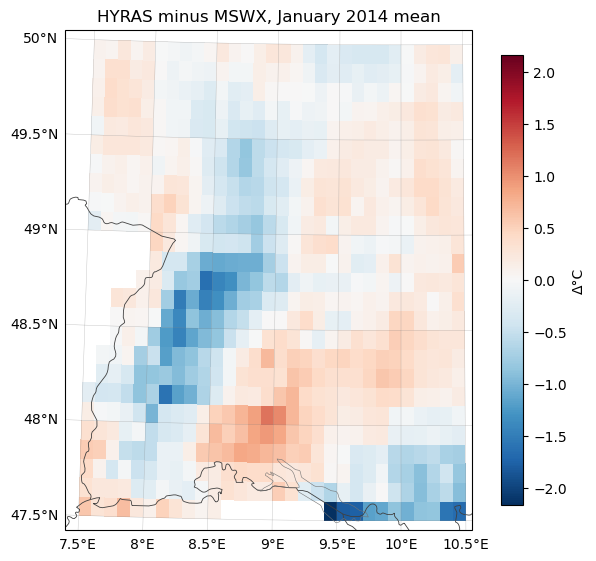

In [14]:
if mswx is not None:
    # Put HYRAS on exactly the MSWX grid, then difference the two.
    hyras_matched = reproject(hyras, like=mswx, method="average")

    difference = hyras_matched.tas.mean("time") - mswx.tas.mean("time")
    print("grids identical:", hyras_matched.sizes == mswx.sizes)
    print(f"mean HYRAS - MSWX: {float(difference.mean()):.3f} °C")

    fig, ax = plt.subplots(figsize=(7, 5.5), subplot_kw={"projection": HYRAS_CRS},
                           constrained_layout=True)
    mesh = difference.plot(ax=ax, transform=PLATE, cmap="RdBu_r",
                           add_colorbar=False, center=0)
    decorate(ax, "HYRAS minus MSWX, January 2014 mean")
    fig.colorbar(mesh, ax=ax, shrink=0.9, pad=0.02).set_label("Δ°C")
    plt.show()
else:
    print("Skipped: MSWX not available.")

## 7. Grid alignment

`align=True` (the default) snaps the grid origin to whole multiples of the resolution.
The payoff: two datasets covering **different extents** still land on identical cell
centres, so they can be differenced without a second interpolation.

Here the same HYRAS field is cropped two different ways and reprojected independently.

In [15]:
west = hyras.isel(x=slice(0, 150))
east = hyras.isel(x=slice(60, None))

west_out = reproject(west, "EPSG:4326", "0.1 deg", method="average")
east_out = reproject(east, "EPSG:4326", "0.1 deg", method="average")

print("west origin:", round(west_out.rio.transform().c, 6))
print("east origin:", round(east_out.rio.transform().c, 6))

shared = set(np.round(west_out.lon.values, 6)) & set(np.round(east_out.lon.values, 6))
print(f"\nshared lon cell-centres: {len(shared)}")

# The real test of co-registration: both grids sit on the same 0.1 deg lattice,
# i.e. every cell centre has the same offset modulo the resolution.
west_offsets = np.unique(np.round(west_out.lon.values % 0.1, 6))
east_offsets = np.unique(np.round(east_out.lon.values % 0.1, 6))
print("west lattice offset:", west_offsets)
print("east lattice offset:", east_offsets)
print("same lattice       :", np.allclose(west_offsets, east_offsets))

west origin: 7.3
east origin: 8.2

shared lon cell-centres: 15
west lattice offset: [0.05]
east lattice offset: [0.05]
same lattice       : True


Because they share cell centres, `xarray` lines them up automatically — no reindexing
and no second interpolation. The residual is not exactly zero because each output was
resampled from a *different* source crop, so cells near the seam see different
neighbourhoods; that is an edge effect, not misalignment.

In [16]:
overlap = west_out.tas.mean("time") - east_out.tas.mean("time")
valid = overlap.notnull().sum().item()
print(f"cells in the overlap        : {valid}")
print(f"max |difference| in overlap : {float(abs(overlap).max()):.2e} °C")

cells in the overlap        : 123
max |difference| in overlap : 6.33e-03 °C


Set `align=False` when you would rather preserve the source extent exactly. The
difference is visible in the grid origin: aligned output starts on a clean multiple of the
resolution, unaligned output starts wherever the reprojected source bounds fell.

(Reprojecting HYRAS *within* EPSG:3035 at 1 km would show no difference at all — its
native grid already sits on a whole-kilometre lattice, which is exactly the property
`align` exists to preserve.)

In [17]:
aligned = reproject(hyras, "EPSG:4326", "0.1 deg", method="average")
exact = reproject(hyras, "EPSG:4326", "0.1 deg", method="average", align=False)

print(f"aligned : {dict(aligned.sizes)}")
print(f"          origin ({aligned.rio.transform().c:.4f}, {aligned.rio.transform().f:.4f})"
      "   <- whole multiples of 0.1")
print(f"exact   : {dict(exact.sizes)}")
print(f"          origin ({exact.rio.transform().c:.4f}, {exact.rio.transform().f:.4f})"
      "   <- wherever the source happened to end")

aligned : {'lon': 34, 'lat': 27, 'time': 31}
          origin (7.3000, 50.1000)   <- whole multiples of 0.1
exact   : {'lon': 32, 'lat': 26, 'time': 31}
          origin (7.3649, 50.0044)   <- wherever the source happened to end


## 8. In the `ClimData` workflow

`target_projection` and `target_resolution` are top-level config options, so they work as
Hydra overrides and slot into the usual extract → process → write chain.

In [18]:
extractor = climdata.ClimData(overrides=[
    "dataset=HYRAS", "variables=[tas]", *BOX, *PERIOD, "data_dir=./data",
    "target_projection=EPSG:4326",
    "target_resolution=0.1 deg",
    "regrid.method=average",
])

extractor.extract()
gridded = extractor.reproject()

print("result:", dict(gridded.sizes), gridded.rio.crs.to_string())
print("staged as reprojected_ds:", extractor.reprojected_ds is not None)

⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/hyras_de/air_temperature_mean/tas_hyras_1_2014_v6-1_de.nc
✔️  Exists locally: ./data/HYRAS/TAS/tas_hyras_1_2014_v6-1_de.nc
result: {'lon': 34, 'lat': 27, 'time': 31} EPSG:4326
staged as reprojected_ds: True


The same run from the command line:

```bash
climdata dataset=HYRAS variables=[tas] \
    time_range.start_date=2014-01-01 time_range.end_date=2014-01-31 \
    target_projection=EPSG:4326 'target_resolution=0.1 deg'
```

The quotes matter because of the space — `target_resolution=0.1deg` also parses, which is
usually easier to type.

The units rule is enforced through the workflow too, and it fires **before** anything is
downloaded:

In [19]:
bad = climdata.ClimData(overrides=[
    "dataset=HYRAS", "variables=[tas]", *BOX, *PERIOD, "data_dir=./data",
    "target_projection=EPSG:4326",
    "target_resolution=1 km",         # linear resolution, geographic CRS
])
bad.current_ds = hyras

try:
    bad.reproject()
except ResolutionCRSMismatch as err:
    print(str(err).split("\n")[0])

target_resolution="1 km" is a linear resolution, but target_projection="EPSG:4326" is a geographic CRS with axis units of degree.


## Summary

| Task | Call |
|---|---|
| Coarsen HYRAS in its own CRS | `reproject(ds, "EPSG:3035", "5 km")` |
| Put HYRAS on the MSWX grid | `reproject(ds, "EPSG:4326", "0.1 deg", method="average")` |
| Match another dataset exactly | `reproject(ds, like=mswx)` |
| Conserve a flux when coarsening | `method="average"`, or `engine="xesmf"` |
| Preserve the source extent | `align=False` |
| Force a metric grid in degrees | `to_angular("1 km", latitude=48.75)` |

**The one rule to remember:** linear resolutions (`"1 km"`) go with projected CRSs like
HYRAS's EPSG:3035; angular resolutions (`"0.1 deg"`) go with geographic CRSs like MSWX's
EPSG:4326. Anything else raises `ResolutionCRSMismatch` — early, before any data moves.